# Diyabet Sınıflandırma Projesi

Bu notebook, **Pima Indians Diabetes** veri seti kullanılarak hastaların diyabet durumunu (Outcome: 0 = sağlıklı, 1 = diyabetli) tahmin etmeye yönelik bir sınıflandırma çalışmasını içerir.

## İçerik
1. Keşifsel Veri Analizi (EDA)
2. Eksik/anlamsız değerlerin (0 → NaN) temizlenmesi
3. Train/Test ayrımı
4. Farklı sınıflandırma modellerinin (Logistic Regression, SVC, Naive Bayes, KNN, Decision Tree, Random Forest, AdaBoost) GridSearchCV ile hiperparametre optimizasyonu
5. Threshold (karar eşiği) denemesi
6. Model karşılaştırma özeti

## Veri Seti
768 gözlem, 8 bağımsız değişken (Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age) ve 1 hedef değişken (Outcome).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df= pd.read_csv("5-)diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
for i in df.columns:
    print(df[i].value_counts())
    print("----------------------\n\n")

Pregnancies
1     135
0     111
2     103
3      75
4      68
5      57
6      50
7      45
8      38
9      28
10     24
11     11
13     10
12      9
14      2
17      1
15      1
Name: count, dtype: int64
----------------------


Glucose
99     17
100    17
111    14
125    14
129    14
       ..
56      1
169     1
149     1
65      1
190     1
Name: count, Length: 136, dtype: int64
----------------------


BloodPressure
70     57
74     52
78     45
68     45
72     44
64     43
80     40
76     39
60     37
0      35
62     34
66     30
82     30
88     25
84     23
90     22
86     21
58     21
50     13
56     12
54     11
52     11
92      8
75      8
65      7
85      6
94      6
48      5
44      4
96      4
110     3
106     3
100     3
98      3
30      2
46      2
55      2
104     2
108     2
40      1
122     1
95      1
102     1
61      1
24      1
38      1
114     1
Name: count, dtype: int64
----------------------


SkinThickness
0     227
32     31
30     27
27    

In [6]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [7]:
df[df["Glucose"]==0]["Glucose"].count()

np.int64(5)

In [8]:
col=["Glucose",	"BloodPressure", "SkinThickness", "Insulin", "BMI"]
for i in col:
    df[col]= df[col].replace(0, np.nan)

In [9]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

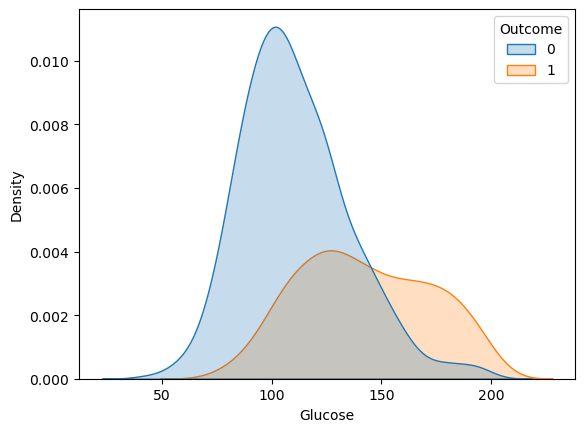

In [10]:
sns.kdeplot(data=df, x="Glucose", hue="Outcome", fill=True)
plt.show()

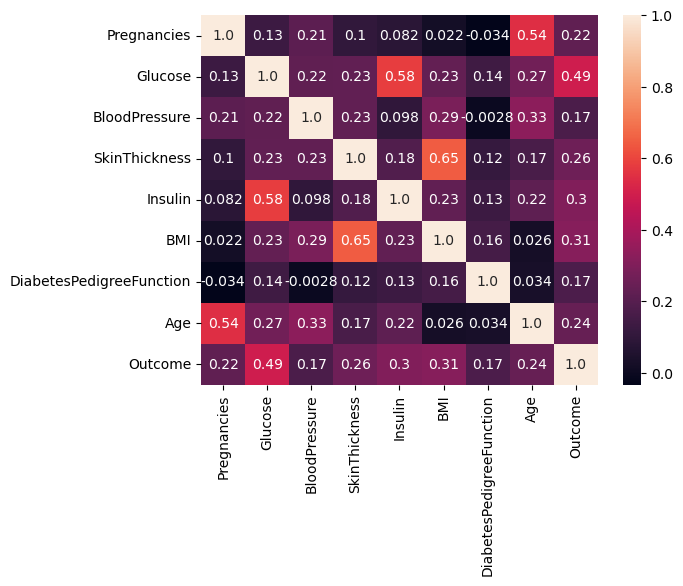

In [11]:
sns.heatmap(df.corr(), annot=True, fmt=".2")
plt.show()

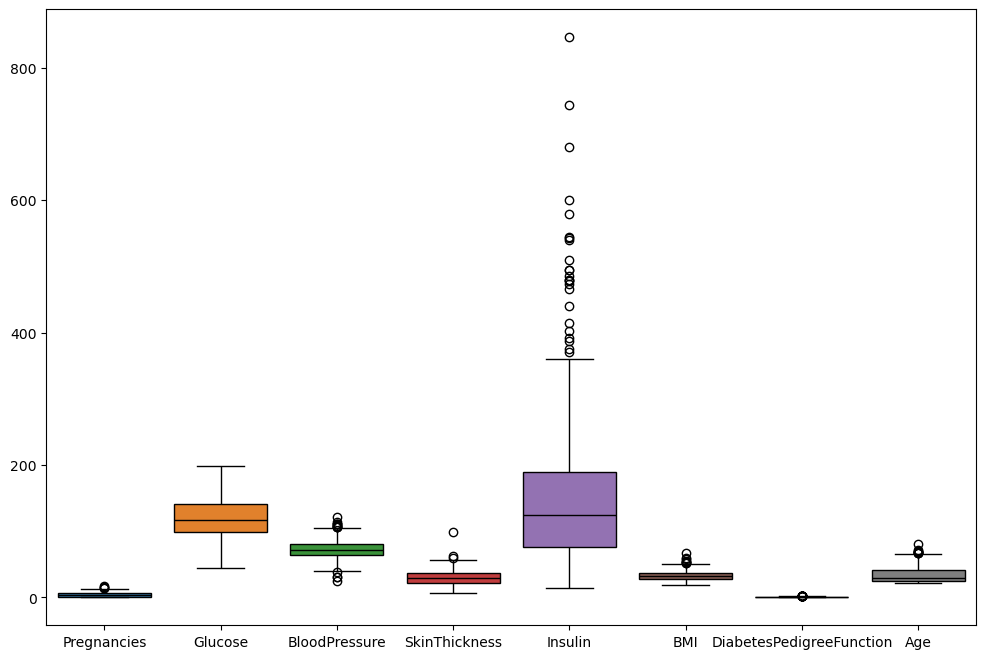

In [12]:
plt.figure(figsize=(12,8))
sns.boxplot(df.drop("Outcome",axis=1),linecolor="black")
plt.show()

In [13]:
X= df.drop("Outcome", axis=1)
y= df["Outcome"]

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [15]:
from sklearn.impute import SimpleImputer

imputer= SimpleImputer(strategy="median")

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score

poly_pipe=Pipeline([
    ("Impute", imputer),
    ("Scaler", StandardScaler()),
    ("Model", LogisticRegression(random_state=15))
])

poly_param={
    "Model__penalty" : ["l1", "l2", "elasticnet", None],
    "Model__solver" : ['lbfgs', 'liblinear', 'saga', 'sag', 'newton-cg'],
    "Model__class_weight" : ["balanced", None],
    "Model__C" : [0.1, 0.5, 1, 1.5, 2]
}

poly_grid= GridSearchCV(estimator=poly_pipe, param_grid=poly_param, cv=5, n_jobs=-1, scoring="roc_auc")
poly_grid.fit(X_train, y_train)
y_pred=poly_grid.predict(X_test)
y_score= poly_grid.predict_proba(X_test)[:,1]

print("ROC-AUC Score:", roc_auc_score(y_test, y_score))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

ROC-AUC Score: 0.802133655394525
Accuracy: 0.7207792207792207
F1 Score: 0.5904761904761905
[[80 28]
 [15 31]]
              precision    recall  f1-score   support

           0       0.84      0.74      0.79       108
           1       0.53      0.67      0.59        46

    accuracy                           0.72       154
   macro avg       0.68      0.71      0.69       154
weighted avg       0.75      0.72      0.73       154



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
450 fits failed out of a total of 1000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 662, in fit
    self._final_estimator.

In [17]:
poly_grid.best_params_

{'Model__C': 0.5,
 'Model__class_weight': 'balanced',
 'Model__penalty': 'l1',
 'Model__solver': 'liblinear'}

In [18]:
from sklearn.svm import SVC

svc_pipe=Pipeline([
    ("Impute", imputer),
    ("Scaler", StandardScaler()),
    ("model", SVC(probability=True, random_state=15))
])

svc_param={
    "model__kernel" : ['linear', 'poly', 'rbf'],
    "model__C" : [0.01, 0.1, 0.5, 1, 10, 100],
    "model__gamma" : ["scale", "auto"]
}

svc_grid= GridSearchCV(estimator=svc_pipe, param_grid=svc_param, cv=5, n_jobs=-1, scoring="roc_auc")
svc_grid.fit(X_train, y_train)
y_pred= svc_grid.predict(X_test)
y_score=svc_grid.predict_proba(X_test)[:,1]

print("ROC-AUC Score:", roc_auc_score(y_test, y_score))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

ROC-AUC Score: 0.8089774557165861
Accuracy: 0.7597402597402597
F1 Score: 0.5747126436781609
[[92 16]
 [21 25]]
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       108
           1       0.61      0.54      0.57        46

    accuracy                           0.76       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.75      0.76      0.76       154



In [19]:
svc_grid.best_params_

{'model__C': 0.01, 'model__gamma': 'scale', 'model__kernel': 'linear'}

In [20]:
from sklearn.naive_bayes import GaussianNB

nb_pipe=Pipeline([
    ("impute", imputer),
    ("scaler", StandardScaler()),
    ("model", GaussianNB())
])

nb_grid=GridSearchCV(estimator=nb_pipe, param_grid={}, cv=5, n_jobs=-1, scoring="roc_auc")
nb_grid.fit(X_train, y_train)
y_pred= nb_grid.predict(X_test)
y_score= nb_grid.predict_proba(X_test)[:, 1]

print("ROC-AUC Score:", roc_auc_score(y_test, y_score))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

ROC-AUC Score: 0.7769726247987118
Accuracy: 0.7207792207792207
F1 Score: 0.5473684210526316
[[85 23]
 [20 26]]
              precision    recall  f1-score   support

           0       0.81      0.79      0.80       108
           1       0.53      0.57      0.55        46

    accuracy                           0.72       154
   macro avg       0.67      0.68      0.67       154
weighted avg       0.73      0.72      0.72       154



In [21]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipe=Pipeline([
    ("imputer", imputer),
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

knn_param={
    "model__n_neighbors" : [3, 5, 7, 10, 15, 30, 40, 50],
    "model__weights" : ["uniform", "distance"],
    "model__metric" : ['euclidean', 'manhattan', 'minkowski'],
    "model__algorithm" : ["auto"]
}

knn_grid= GridSearchCV(estimator=knn_pipe, param_grid=knn_param, cv=5, n_jobs=-1, scoring="roc_auc")
knn_grid.fit(X_train, y_train)
y_pred= knn_grid.predict(X_test)
y_score= knn_grid.predict_proba(X_test)[:,1]

print("ROC-AUC Score:", roc_auc_score(y_test, y_score))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

ROC-AUC Score: 0.7836151368760065
Accuracy: 0.7467532467532467
F1 Score: 0.5617977528089888
[[90 18]
 [21 25]]
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       108
           1       0.58      0.54      0.56        46

    accuracy                           0.75       154
   macro avg       0.70      0.69      0.69       154
weighted avg       0.74      0.75      0.74       154



In [22]:
knn_grid.best_params_

{'model__algorithm': 'auto',
 'model__metric': 'manhattan',
 'model__n_neighbors': 50,
 'model__weights': 'distance'}

In [23]:
from sklearn.tree import DecisionTreeClassifier

tree_pipe=Pipeline([
    ("imputer", imputer),
    ("model", DecisionTreeClassifier(random_state=15))
])

tree_param={
    "model__criterion" : ["gini", "entropy"],
    "model__max_depth" : [5, 10, 15 ,None],
    "model__min_samples_split" : [5, 7, 10],
    "model__min_samples_leaf" : [5, 7, 10],
    "model__max_features" : ["sqrt", "log2", None]
}

tree_grid= GridSearchCV(estimator=tree_pipe, param_grid=tree_param, cv=5, n_jobs=-1, scoring="roc_auc")
tree_grid.fit(X_train, y_train)
y_pred= tree_grid.predict(X_test)
y_score= tree_grid.predict_proba(X_test)[:,1]

print("ROC-AUC Score:", roc_auc_score(y_test, y_score))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

ROC-AUC Score: 0.7715378421900161
Accuracy: 0.7402597402597403
F1 Score: 0.5918367346938775
[[85 23]
 [17 29]]
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       108
           1       0.56      0.63      0.59        46

    accuracy                           0.74       154
   macro avg       0.70      0.71      0.70       154
weighted avg       0.75      0.74      0.74       154



In [24]:
tree_grid.best_params_

{'model__criterion': 'entropy',
 'model__max_depth': 5,
 'model__max_features': None,
 'model__min_samples_leaf': 10,
 'model__min_samples_split': 5}

In [25]:
from sklearn.ensemble import RandomForestClassifier

rfc_pipe= Pipeline([
    ("imputer", imputer),
    ("model", RandomForestClassifier(random_state=15))
])

rfc_param={
    "model__criterion" : ["gini", "entropy"],
    "model__max_depth" : [5, 10, 15 ,None],
    "model__min_samples_split" : [5, 7, 10],
    "model__min_samples_leaf" : [5, 7, 10],
    "model__max_features" : ["sqrt", "log2", None],

    "model__n_estimators" : [100, 200, 400, 500],
    
}

rfc_grid= GridSearchCV(estimator=rfc_pipe, param_grid=rfc_param, n_jobs=-1, cv=5, scoring="roc_auc")
rfc_grid.fit(X_train, y_train)
y_pred= rfc_grid.predict(X_test)
y_score= rfc_grid.predict_proba(X_test)[:, 1]

print("ROC-AUC Score:", roc_auc_score(y_test, y_score))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

ROC-AUC Score: 0.7876409017713366
Accuracy: 0.7402597402597403
F1 Score: 0.5918367346938775
[[85 23]
 [17 29]]
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       108
           1       0.56      0.63      0.59        46

    accuracy                           0.74       154
   macro avg       0.70      0.71      0.70       154
weighted avg       0.75      0.74      0.74       154



In [26]:
rfc_grid.best_params_

{'model__criterion': 'entropy',
 'model__max_depth': 15,
 'model__max_features': 'log2',
 'model__min_samples_leaf': 5,
 'model__min_samples_split': 5,
 'model__n_estimators': 400}

In [27]:
from sklearn.ensemble import AdaBoostClassifier

abc_pipe= Pipeline([
    ("imputer", imputer),
    ("model", AdaBoostClassifier(random_state=15))
])

abc_param={
    "model__n_estimators" : [50, 100 , 300, 500],
    "model__learning_rate" : [0.01, 0.1, 0.5, 1, 2]
}

abc_grid= GridSearchCV(estimator=abc_pipe, param_grid=abc_param, cv=5, n_jobs=-1, scoring="roc_auc")
abc_grid.fit(X_train, y_train)
y_pred= abc_grid.predict(X_test)
y_score= abc_grid.predict_proba(X_test)[:,1]

print("ROC-AUC Score:", roc_auc_score(y_test, y_score))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

ROC-AUC Score: 0.8012278582930756
Accuracy: 0.7532467532467533
F1 Score: 0.5869565217391305
[[89 19]
 [19 27]]
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       108
           1       0.59      0.59      0.59        46

    accuracy                           0.75       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.75      0.75      0.75       154



In [28]:
abc_grid.best_params_

{'model__learning_rate': 0.5, 'model__n_estimators': 300}

In [39]:
from sklearn.metrics import roc_curve

#RandomForest
rfc_prob=rfc_grid.best_estimator_.predict_proba(X_test)[:,1]
custom_th=0.3
y_pred_custom=(rfc_prob >= custom_th).astype(int)
print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))


[[75 33]
 [ 9 37]]
              precision    recall  f1-score   support

           0       0.89      0.69      0.78       108
           1       0.53      0.80      0.64        46

    accuracy                           0.73       154
   macro avg       0.71      0.75      0.71       154
weighted avg       0.78      0.73      0.74       154



In [41]:
#RandomForest
rfc_prob=rfc_grid.best_estimator_.predict_proba(X_test)[:,1]
custom_th=0.2
y_pred_custom=(rfc_prob >= custom_th).astype(int)
print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))

[[62 46]
 [ 7 39]]
              precision    recall  f1-score   support

           0       0.90      0.57      0.70       108
           1       0.46      0.85      0.60        46

    accuracy                           0.66       154
   macro avg       0.68      0.71      0.65       154
weighted avg       0.77      0.66      0.67       154



In [46]:
#KNNImputer and IteratıveImputer
from sklearn.impute import KNNImputer
svc_pipe_KI=Pipeline([
    ("Impute", KNNImputer(n_neighbors=5)),
    ("Scaler", StandardScaler()),
    ("model", SVC(probability=True, random_state=15))
])

svc_param_KI={
    "model__kernel" : ['linear', 'poly', 'rbf'],
    "model__C" : [0.01, 0.1, 0.5, 1, 10, 100],
    "model__gamma" : ["scale", "auto"]
}

svc_grid_KI= GridSearchCV(estimator=svc_pipe_KI, param_grid=svc_param, cv=5, n_jobs=-1, scoring="roc_auc")
svc_grid_KI.fit(X_train, y_train)
y_pred= svc_grid_KI.predict(X_test)
y_score=svc_grid_KI.predict_proba(X_test)[:,1]

print("ROC-AUC Score:", roc_auc_score(y_test, y_score))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

ROC-AUC Score: 0.8099838969404186
Accuracy: 0.7597402597402597
F1 Score: 0.5747126436781609
[[92 16]
 [21 25]]
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       108
           1       0.61      0.54      0.57        46

    accuracy                           0.76       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.75      0.76      0.76       154



In [47]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

svc_pipe_II=Pipeline([
    ("Impute", IterativeImputer()),
    ("Scaler", StandardScaler()),
    ("model", SVC(probability=True, random_state=15))
])

svc_param_II={
    "model__kernel" : ['linear', 'poly', 'rbf'],
    "model__C" : [0.01, 0.1, 0.5, 1, 10, 100],
    "model__gamma" : ["scale", "auto"]
}

svc_grid_II= GridSearchCV(estimator=svc_pipe_II, param_grid=svc_param, cv=5, n_jobs=-1, scoring="roc_auc")
svc_grid_II.fit(X_train, y_train)
y_pred= svc_grid_II.predict(X_test)
y_score=svc_grid_II.predict_proba(X_test)[:,1]

print("ROC-AUC Score:", roc_auc_score(y_test, y_score))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

ROC-AUC Score: 0.8079710144927537
Accuracy: 0.7597402597402597
F1 Score: 0.5842696629213483
[[91 17]
 [20 26]]
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       108
           1       0.60      0.57      0.58        46

    accuracy                           0.76       154
   macro avg       0.71      0.70      0.71       154
weighted avg       0.76      0.76      0.76       154



# Sonuç ve Değerlendirme

## Model Karşılaştırma Tablosu

| Model | ROC-AUC | Accuracy | F1 Score |
|---|---|---|---|
| SVC (KNNImputer) | 0.8100 | 0.7597 | 0.5747 |
| SVC (median imputer) | 0.8090 | 0.7597 | 0.5747 |
| SVC (IterativeImputer) | 0.8080 | 0.7597 | 0.5843 |
| AdaBoost | 0.8012 | 0.7532 | 0.5870 |
| Logistic Regression | 0.8021 | 0.7208 | 0.5905 |
| Random Forest | 0.7876 | 0.7403 | 0.5918 |
| KNN | 0.7836 | 0.7468 | 0.5618 |
| Naive Bayes | 0.7770 | 0.7208 | 0.5474 |
| Decision Tree | 0.7715 | 0.7403 | 0.5918 |

## Threshold (Karar Eşiği) Denemesi — Random Forest

| Threshold | Precision (1) | Recall (1) | Accuracy |
|---|---|---|---|
| 0.5 (varsayılan) | 0.56 | 0.63 | 0.74 |
| 0.3 | 0.53 | 0.80 | 0.73 |
| 0.2 | 0.46 | 0.85 | 0.66 |

Eşik düşürüldükçe recall artıyor (daha az hasta kaçırılıyor) ama precision düşüyor. Nihai eşik seçimi kullanım amacına göre yapılmalı: ön tarama ise düşük eşik, kesin tanı destekli bir sistemse 0.4–0.5 civarı daha dengeli olur.

## Eksik Veri İmputasyon Yöntemi Karşılaştırması (SVC üzerinde)
Üç imputasyon yöntemi (median, KNN, Iterative) SVC üzerinde karşılaştırıldığında:
- **ROC-AUC** açısından aralarında pratik olarak anlamlı bir fark yok (0.8080–0.8100 arası, ~0.002 fark).
- **IterativeImputer**, diğer ikisine göre daha iyi F1 skoru (0.5843) vermiştir; bunun nedeni recall'ın hafifçe artması (confusion matrix'te FN 21→20, TP 25→26).
- **Accuracy** üç yöntemde de birebir aynı (0.7597) kalmıştır.

Bu veri setinde imputasyon yönteminin model performansı üzerindeki etkisi sınırlı; IterativeImputer hafif bir recall/F1 avantajı sunuyor ama karar verirken hesaplama maliyetini de göz önünde bulundurmak gerekir (Iterative > KNN > median, işlem süresi açısından).

## Genel Gözlemler
- Modeller arasındaki performans farkı büyük değil; bu, veri setinin doğal tavanına (~0.80 ROC-AUC civarı) işaret ediyor.
- Recall tüm modellerde precision'dan düşük kalıyor — sınıf dengesizliğinden (500 sağlıklı / 268 diyabetli) kaynaklanıyor.
- İmputasyon yöntemi bu veri setinde ROC-AUC'ı anlamlı değiştirmiyor, ama F1/recall üzerinde IterativeImputer hafif bir avantaj sağlıyor.